# ROIC — the "quality compounder" number. Does it actually sort stocks? 🏭
### Strip leverage out of ROE, divide unlevered profit by all the capital deployed — and discover it forecasts nothing on the mega-caps everyone owns

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds over ROE%2FGP%3F: No](https://img.shields.io/badge/Adds_over_ROE%2FGP%3F-No-8b949e?style=flat-square)

Return on **invested capital** is the number quality investors swear by. The pitch: return on **equity** (ROE) can be juiced by borrowing — pile on debt or buy back stock and ROE goes up without the business getting any better. **ROIC** fixes that. It takes *unlevered* operating profit (NOPAT) and divides by **all** the capital the business actually uses — debt **plus** equity **minus** cash. High, steady ROIC is supposed to be the fingerprint of a wide-moat compounder; low ROIC flags a capital-destroyer. So: buy the high-ROIC names, short the low-ROIC ones, collect the quality premium.

We ran it on 32 of the biggest US companies. It sorts **nothing** — and the plainer signals it's supposed to improve on do even worse.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 44 large US non-financial names (32 yield a valid ROIC) from EDGAR, 2009→2026; a genuinely **thin** panel and a **current-survivors** basket. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from roic_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_names_basket': 44, 'n_events': 844, 'end_lo': '2009-06-27', 'end_hi': '2026-05-29', 'fp_prices': '030498da471a', 'n_months': 202, 'avg_n': 16.5, 'ls_span_lo': '2009-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 13.5, 'ls_ann': 1.62, 'ls_t_iid': 0.48, 'ls_t_nw': 0.4, 'ls_sharpe': 0.12, 'ls_hit': 50, 'ls_long_bps': 179.3, 'ls_short_bps': 165.8, 'ls_turn': 0.06, 'ls120_mean_bps': 37.2, 'ls120_t_nw': 1.12, 'chg_mean_bps': 32.1, 'chg_t_nw': 1.14, 'chg_sharpe': 0.28, 'chg_n': 189, 'drift': {21: (840, 1.23, 0.96, 0.27, 0.47, 50, 0.3096), 63: (818, 4.94, 4.58, 0.37, 0.29, 51, 0.3615), 126: (811, 8.37, 10.05, -1.68, -0.85, 51, 0.8228)}, 'mono63': (4.58, 5.0, 4.94), 'era_early_n': 100, 'era_early_bps': -5.6, 'era_early_t': -0.14, 'era_late_n': 102, 'era_late_bps': 32.2, 'era_late_t': 0.6, 'contrast': {'roic': (13.5, 0.4, 0.12, 202), 'roic_chg': (32.1, 1.14, 0.28, 189), 'roe': (-65.5, -1.36, -0.5, 89), 'gp': (-164.1, -1.59, -0.85, 60)}, 'roic_roe_rank_corr': 0.752, 'net': {(10, 50): (8.1, 0.98, 0.24, 0.07), (20, 100): (2.8, 0.33, 0.08, 0.02)}, 'syn_null_mean': -0.38, 'syn_null_sd': 1.43, 'syn_null_fire': 2, 'syn_null_seeds': 12, 'syn_planted_bps': 825.4, 'syn_planted_t': 23.63}


real cache present: True | events: 844 | names: 32


## The answer first

| Question | Answer |
|---|---|
| Does high ROIC beat low ROIC in future **returns**? | **No.** A long-short that buys the top third and shorts the bottom third earns **+1.6%/yr** on paper — but that's statistical zero (robust *t* = **+0.40**, the bar is 2). |
| Is it at least consistent? | **No.** Over 2 quarters the high-ROIC names actually *under*-perform; and the spread's sign **flips** between the pre-2018 and post-2018 halves of the sample. |
| Does ROIC beat plain **ROE** / **gross profitability**? | **It's moot — none of them work here.** On these mega-caps ROE and gross profitability come out *negative*; ROIC is just the least bad. And ROIC tracks ROE **+0.75** — basically the same bet with the leverage scrubbed off. |
| Why? | The quality premium lives in **smaller, junkier** companies. A basket of 44 giant survivors is exactly where it's weakest — the capital-destroyers you'd want to short already got bought or delisted. |

> A beautiful ratio with real accounting logic — that forecasts the *business* far better than it forecasts the *stock*, and among mega-caps forecasts the stock not at all.

## 1 · The claim

> *"ROE lies when a company is levered. ROIC doesn't — it's unlevered profit over all the capital at work. Buy high ROIC, short low ROIC, harvest quality."*

It's a respectable idea. Profitability **is** a compensated factor in the academic record (Novy-Marx 2013; Fama-French 2015; AQR's Quality-Minus-Junk). The question is whether **this specific, unlevered, cash-adjusted** version of return-on-capital earns a spread — and whether making the ratio 'cleaner' than ROE actually buys you anything.

## 2 · So what?

If a tidy balance-sheet ratio sorted the returns of the most-analysed companies on earth, it would be the easiest money in the market — every value fund computes ROIC. That ubiquity is the reason to be suspicious: a number this famous, on names this scrutinised, is exactly the kind the market should already price.

## 3 · How would we even know?

- **The signal.** For each of 32 big non-financial names, ROIC = unlevered operating profit (a full trailing year) ÷ invested capital (debt + equity − cash), known only on the **filing date** of the 10-Q/10-K — never before the number is public.
- **The return test.** Each month, rank the names on ROIC, buy the top third, short the bottom third, hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The head-to-head.** Run the *same* test on plain ROE and on gross profitability. Does the 'cleaner' ROIC actually beat them?
- **The mirage check.** If the spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**The money question first: do high-ROIC stocks out-return low-ROIC stocks?** We rank the names into thirds each month and track the long-top / short-bottom portfolio.

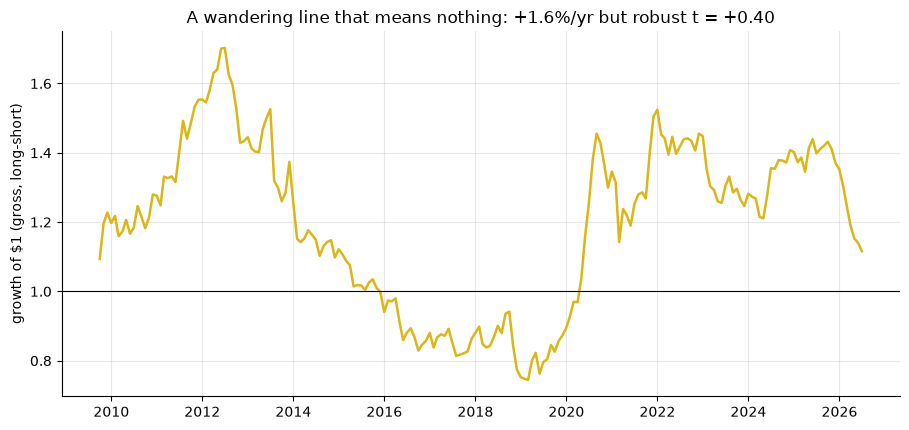

long-short: +1.6%/yr gross, but Newey-West t = +0.40 (the bar is 2)


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='roic', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=AMBER, lw=1.8); ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A wandering line that means nothing: +{ann:.1f}%/yr but robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: +{ann:.1f}%/yr gross, but Newey-West t = {tnw:+.2f} (the bar is 2)')

It drifts around **+1.6%/yr** gross — but that's a rounding error, and the robust *t*-statistic is **+0.40**, nowhere near the **2** we require to call something real. This is what *nothing* looks like: a faint wobble the statistics can't distinguish from zero.

**The tell:** if ROIC really sorted returns, the thirds would form a ladder — bottom lowest, top highest. Watch what they actually do over the next quarter.

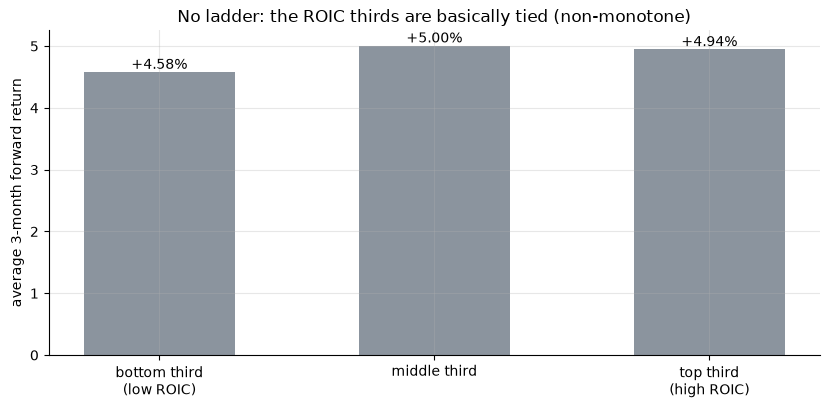

3-month forward return by ROIC third (low->high): ['+4.58%', '+5.00%', '+4.94%']


In [3]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom third\n(low ROIC)','middle third','top third\n(high ROIC)'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('No ladder: the ROIC thirds are basically tied (non-monotone)')
plt.tight_layout(); plt.show()
print('3-month forward return by ROIC third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase. The middle third is the *highest*, the top and bottom are tied — and if you stretch the horizon to two quarters (in the quants notebook) the high-ROIC third actually *under*-performs. There is no monotone quality ladder here.

**Now the headline question: is ROIC at least better than the plainer signals it claims to improve on?** Same long-short, run on ROIC, on plain ROE, and on gross profitability.

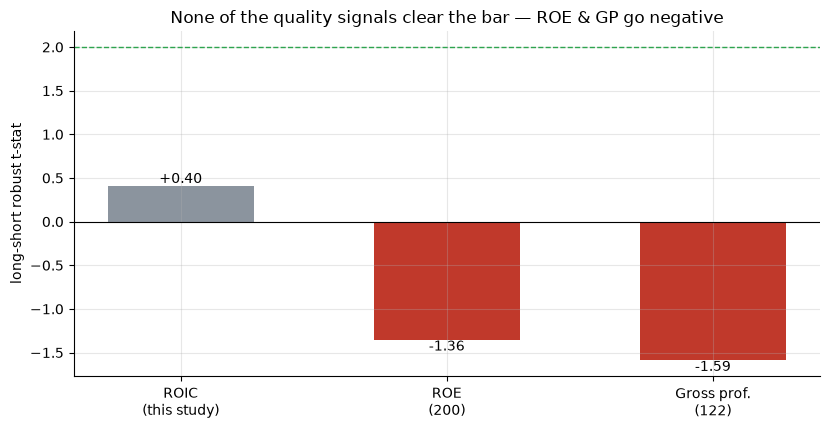

robust t by signal: {'ROIC': 0.4, 'ROE': -1.36, 'Gross prof.': -1.59}


In [4]:
sigs = ['roic','roe','gp']; labels=['ROIC\n(this study)','ROE\n(200)','Gross prof.\n(122)']
if HAVE_REAL:
    ts = []
    for c in sigs:
        lc = st.calendar_ls(PX, EV, signal_col=c, n_buckets=3, min_names=6, staleness_days=200)
        ts.append(st.calendar_ls_stats(lc)['t_nw'])
else:
    ts = [R['contrast'][c][1] for c in sigs]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
cols = [GREY if t>0 else RED for t in ts]
ax.bar(labels, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(ts): ax.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('long-short robust t-stat'); ax.set_title('None of the quality signals clear the bar — ROE & GP go negative')
plt.tight_layout(); plt.show()
print('robust t by signal:', {l.split(chr(10))[0]: round(t,2) for l,t in zip(labels,ts)})

There it is. **None** of them work on these mega-caps — and plain ROE (-1.36) and gross profitability (-1.59) are actually *negative*. ROIC (+0.40) is merely the least bad. And because ROIC and ROE move together (rank correlation **+0.75**), the 'cleaner' ratio is largely the same bet with the leverage scrubbed off. Stripping leverage out of ROE changed the story not at all.

## 5 · The verdict

- **Signal — None.** ROIC does not sort returns here: +1.6%/yr gross, robust *t* = +0.40, thirds non-monotone, sign flips across eras.
- **Tradability — Mirage.** It's zero before costs; there's nothing to charge costs against.
- **Does ROIC add anything over ROE / gross profitability? — No.** None of the quality signals certify on mega-cap survivors; ROIC is only the least bad and tracks ROE +0.75.

> The honest one-liner: *ROIC is a great way to describe a business and a useless way to rank the biggest stocks — and making the ratio 'cleaner' than ROE buys you nothing.*

## 6 · Going further 🚪

- **Where the premium actually lives.** The quality/profitability factor is strongest in **small, junky, distress-prone** names — precisely the cross-section a mega-cap **survivor** basket excludes. A live, point-in-time small-cap universe (with the delisted names still in it) is where this test would have teeth.
- **The survivorship trap is on the short side.** Our low-ROIC short leg can only hold companies that *survived* to today; the genuine capital-destroyers were acquired or delisted, so the short leg is defanged by construction.
- **Sibling studies:** [200-roe-quality](../../200-roe-quality/) (levered ROE), [122-gross-profitability](../../122-gross-profitability/) (GrossProfit/Assets), [242-quality-minus-junk](../../242-quality-minus-junk/) (the AQR composite), and [521-cash-based-operating-profitability](../../521-cash-based-operating-profitability/) (accruals stripped from the numerator). See [docs/references.md](../docs/references.md) for the exact dedup.

*Think ROIC earns a premium on a live small-cap tape with the dead names included? Build it, show a certifiable net spread on the size you'd actually run — then we'll talk.*